170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


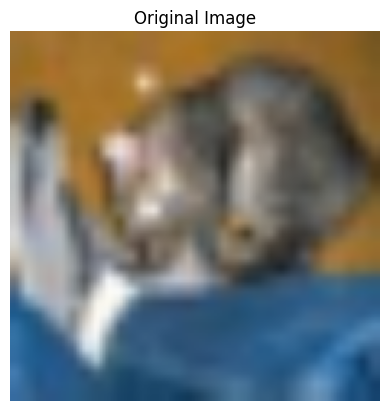

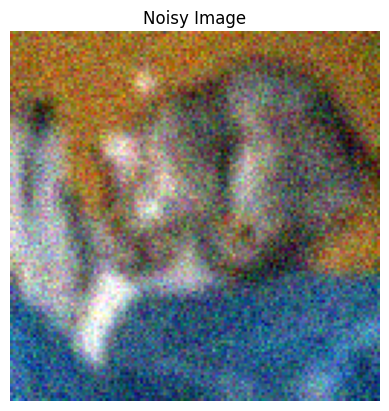

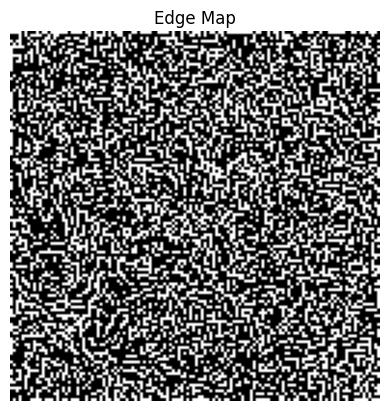

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0356
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - loss: 0.0326
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - loss: 0.0309
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 0.0289
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - loss: 0.0263
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.0237
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 0.0212
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - loss: 0.0193
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 0.0181
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.0174
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - loss: 0.0166
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.0156
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - loss: 0.0141
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - loss: 0.0127
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 0.0113
Epoch 16/20
1/1 ━━━━━━

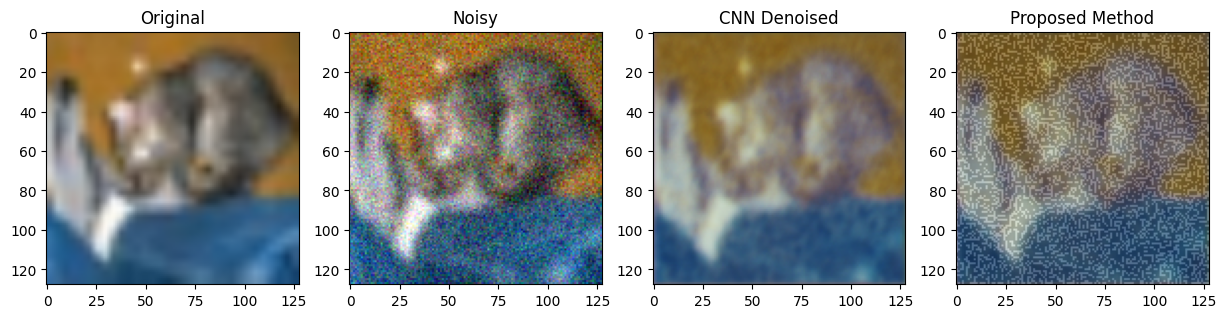

PSNR: 17.870341248852807
SSIM: 0.2121547920092546


In [ ]:
# ================================
# 1. Import Libraries
# ================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras import layers, models
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity


# ================================
# 2. Load CIFAR10 Image
# ================================

(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

img = x_test[0]

img = cv2.resize(img,(128,128))

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()


# ================================
# 3. Add Gaussian Noise
# ================================

noise = np.random.normal(0,25,img.shape)

noisy = img + noise
noisy = np.clip(noisy,0,255).astype(np.uint8)

plt.imshow(noisy)
plt.title("Noisy Image")
plt.axis("off")
plt.show()


# ================================
# 4. Edge Detection
# ================================

edges = cv2.Canny(noisy,100,200)

plt.imshow(edges,cmap='gray')
plt.title("Edge Map")
plt.axis("off")
plt.show()


# ================================
# 5. Build CNN Denoiser
# ================================

def build_denoiser():

    input_img = layers.Input(shape=(128,128,3))

    x = layers.Conv2D(64,(3,3),activation='relu',padding='same')(input_img)
    x = layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)
    x = layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)

    output = layers.Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)

    model = models.Model(input_img,output)

    model.compile(optimizer='adam',loss='mse')

    return model

model = build_denoiser()


# ================================
# 6. Prepare Training Data
# ================================

x_train = noisy/255.0
y_train = img/255.0

x_train = np.expand_dims(x_train,axis=0)
y_train = np.expand_dims(y_train,axis=0)


# ================================
# 7. Train Model
# ================================

model.fit(x_train,y_train,epochs=20,verbose=1)


# ================================
# 8. CNN Denoising
# ================================

denoised = model.predict(x_train)[0]

denoised = (denoised*255).astype(np.uint8)


# ================================
# 9. Edge-Aware Fusion (Proposed Method)
# ================================

edges_rgb = cv2.cvtColor(edges,cv2.COLOR_GRAY2RGB)

final = cv2.addWeighted(denoised,0.8,edges_rgb,0.2,0)


# ================================
# 10. Show Results
# ================================

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,4,2)
plt.imshow(noisy)
plt.title("Noisy")

plt.subplot(1,4,3)
plt.imshow(denoised)
plt.title("CNN Denoised")

plt.subplot(1,4,4)
plt.imshow(final)
plt.title("Proposed Method")

plt.show()


# ================================
# 11. Evaluation Metrics
# ================================

psnr = peak_signal_noise_ratio(img,final)

ssim = structural_similarity(img,final,channel_axis=2)

print("PSNR:",psnr)
print("SSIM:",ssim)

### Visual Comparison: Original vs. Denoised Image

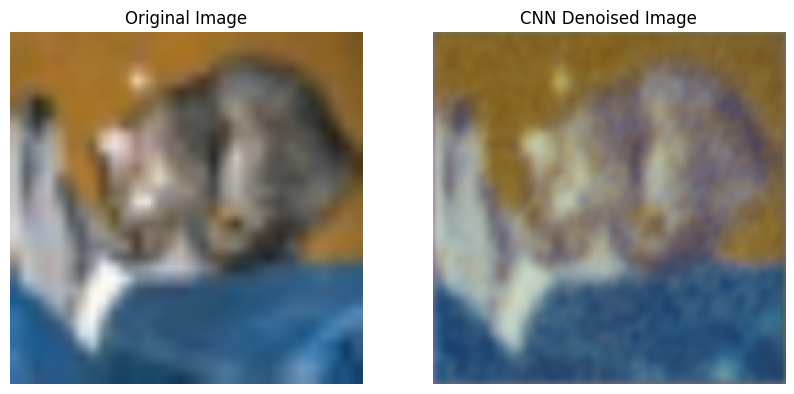

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denoised)
plt.title("CNN Denoised Image")
plt.axis("off")

plt.show()